# Tutorial 2 — Nonlinear Dynamics: Coupled Oscillators in Fly Walking

**BAMB! 2026 — Module 5: Complex Motor Behavior**

---

In Tutorial 1 we modeled **zebrafish swimming bouts** with a Switching Linear Dynamical System. Each bout was a *transient* decaying oscillation — a damped spiral into a fixed point. Linear dynamics worked because the system never needs to *maintain* its amplitude; bouts simply run down.

**Fly walking is different.** The fly keeps walking. Leg oscillations do not decay between steps; they maintain a fixed amplitude indefinitely. After a perturbation, leg rhythms *recover* — amplitude and phase relationships return to exactly where they were.

We will build up our model in three stages, each motivated by a failure of the previous one:

| Stage | Model | What it captures | What it misses |
|---|---|---|---|
| 1 | **Linear (LDS)** baseline | One-step prediction | Long-run amplitude stability |
| 2 | **Kuramoto** | Phase coordination, gait topology | Amplitude, onset/offset |
| 3 | **Stuart-Landau (Hopf)** | Amplitude + phase, perturbation recovery | Same limit as Kuramoto far from r* |

One insight we will build toward: **Kuramoto is what you get when you look at Stuart-Landau near the limit cycle.**

In [4]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

#import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(58)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'lines.linewidth': 1.8,
})
print('Setup complete.')

Setup complete.


---
## Part 1 — Fly walking data

Load the leg position data from two legs of a walking fly and visualize the data.

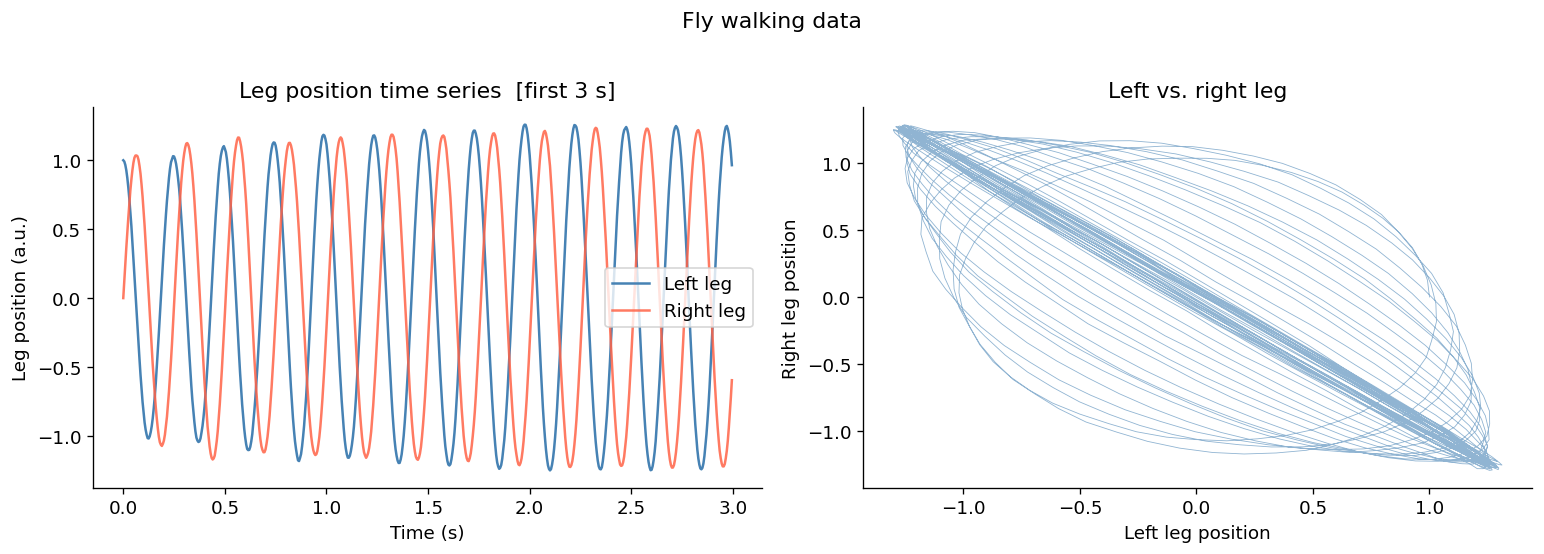

Sampling rate: 200 Hz  |  Duration: 7.995 s  |  N = 1600 frames


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/bambschool/BAMB2026/main/Module%205/data/fly_data.csv')
dt = df.t[1] - df.t[0]
T_sim = df.iloc[-1].t
N = len(df.t)


# ─── Figure: The data ───────────────────────────────────────────
theta_lc = np.linspace(0, 2*np.pi, 300)
n_show = int(3.0 / dt)
skip   = int(0.5 / dt)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(df.t[:n_show], df.x_L[:n_show], 'steelblue', lw=1.5, label='Left leg')
ax.plot(df.t[:n_show], df.x_R[:n_show], 'tomato',    lw=1.5, alpha=0.85, label='Right leg')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Leg position (a.u.)')
ax.set_title('Leg position time series  [first 3 s]')
ax.legend()

ax = axes[1]
ax.plot(df.x_L, df.x_R, color='steelblue', lw=0.5, alpha=0.6)
ax.set_xlabel('Left leg position'); ax.set_ylabel('Right leg position')
ax.set_title('Left vs. right leg')

plt.suptitle('Fly walking data', y=1.02)
plt.tight_layout(); plt.show()

print(f'Sampling rate: {1/dt:.0f} Hz  |  Duration: {T_sim} s  |  N = {N} frames')

**We observe that left and right leg position are negatively correlated, they are in anti-phase**

---
## Part 2 — Extracting amplitudes and phases from data via the Hilbert transform

To fit dynamical models, we need amplitudes $r_k(t)$ and phases $\theta_k(t)$ from the observable $x_k(t)$. The **analytic signal** gives us this:

$$z_k(t) = x_k(t) + i\hat{x}_k(t) = r_k(t)\, e^{i\theta_k(t)}$$

where $\hat{x}_k$ is the Hilbert transform of $x_k$ (the 90°-shifted version). From this we extract:
- **Instantaneous amplitude**: $r_k(t) = |z_k(t)|$
- **Instantaneous phase**: $\theta_k(t) = \arg(z_k(t))$

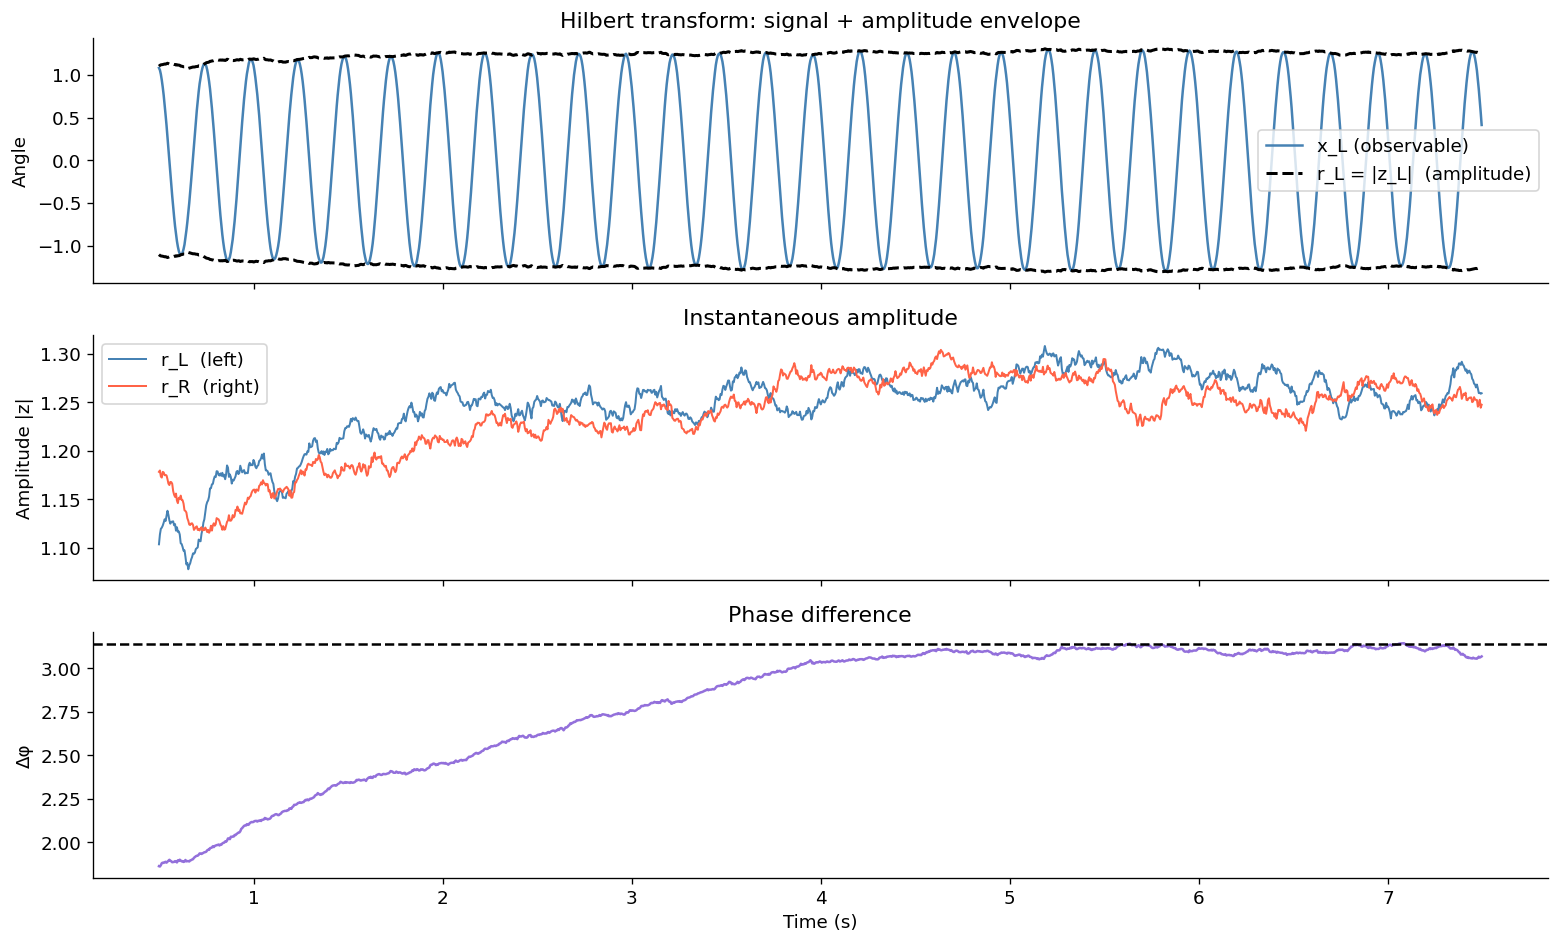

Mean amplitude:  left = 1.247,  right = 1.236
Mean phase diff: 2.806 (expected π = anti-phase)


In [311]:
# ─── Hilbert transform: extract amplitude and phase ───────────────
margin = int(0.5 / dt)   # trim edge transients (Hilbert distorts both ends of the signal)

z_L_full = sig.hilbert(df.x_L)
z_R_full = sig.hilbert(df.x_R)

keep = slice(margin, -margin)
x_L, x_R = df.x_L[keep], df.x_R[keep]
t = df.t[keep]

z_L_h   = z_L_full[keep]
z_R_h   = z_R_full[keep]
r_L_h   = np.abs(z_L_h)  # instantaneous amplitude of left leg 
r_R_h   = np.abs(z_R_h)  # instantaneous amplitude of right leg 
phi_L_h = np.unwrap(np.angle(z_L_h))  # instantaneous phase of left leg 
phi_R_h = np.unwrap(np.angle(z_R_h))  # instantaneous phase of right leg 


# ─── Figure: Hilbert transform ───────────────────────────────────────────

n_disp = int(7.0 / dt)
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(t[:n_disp], x_L[:n_disp], 'steelblue', lw=1.5, label='x_L (observable)')
ax.plot(t[:n_disp],  r_L_h[:n_disp], 'k--', lw=1.8, label='r_L = |z_L|  (amplitude)')
ax.plot(t[:n_disp], -r_L_h[:n_disp], 'k--', lw=1.8)
ax.set_ylabel('Angle'); ax.set_title('Hilbert transform: signal + amplitude envelope')
ax.legend()

ax = axes[1]
ax.plot(t[:n_disp], r_L_h[:n_disp], 'steelblue', lw=1.2, label='r_L  (left)')
ax.plot(t[:n_disp], r_R_h[:n_disp], 'tomato',    lw=1.2, label='r_R  (right)')
ax.set_ylabel('Amplitude |z|')
ax.set_title('Instantaneous amplitude')
ax.legend()

ax = axes[2]
dphi_trace = (phi_L_h - phi_R_h)[:n_disp] % (2*np.pi)
ax.plot(t[:n_disp], dphi_trace, 'mediumpurple', lw=1.5)
ax.axhline(np.pi, color='k', ls='--', lw=1.5)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Δφ')
ax.set_title('Phase difference')

plt.tight_layout(); plt.show()

print(f'Mean amplitude:  left = {r_L_h.mean():.3f},  right = {r_R_h.mean():.3f}')
dphi_all = (phi_L_h - phi_R_h) % (2*np.pi)
print(f'Mean phase diff: {np.mean(dphi_all):.3f} (expected π = anti-phase)')

- **After an initial transient, the amplitudes fluctuate around a constant value.**
- **The phase difference is maintained near π, as expected in alternating tripod gait.**

---
## Part 3 — Stage 1: Fitting a linear dynamical system

### 3.1 Why even consider a linear model?

From Tutorial 1, our default toolkit is the LDS: fit a matrix $A$ by OLS such that $z_{t+1} \approx Az_t$. This works beautifully for transient dynamics. Let's see what happens when we apply it to sustained walking.

### 3.2 Why a linear dynamical system fails to explain stable walking behavior

We fit the *discrete-time dynamical system* $z_{t+1} = Az_t$. Oscillatory modes come in complex-conjugate eigenvalue pairs $\lambda = |\lambda|\,e^{\pm i\theta}$, where $\theta = \omega \Delta t$ is the rotation angle per sample. The amplitude evolves as $|\lambda|^n$ over $n$ steps:
- $|\lambda| < 1$: decays (zebrafish bouts ✓, fly walking ✗)
- $|\lambda| = 1$: constant amplitude — but **structurally unstable**: any noise pushes $|\lambda|$ off 1, and the perturbation compounds every step, growing or decaying without bound. There is no restoring force.
- $|\lambda| > 1$: grows without bound

(This is the discrete-time analogue of the continuous-time picture $\dot z = Az$, $\lambda_{\text{cont}} = \sigma \pm i\omega$, related by $\lambda = e^{\lambda_{\text{cont}}\Delta t}$ — so $|\lambda|=1 \iff \sigma=0$.)

No linear system can robustly maintain finite-amplitude oscillations. We will see later that the restoring force is fundamentally nonlinear.


In [291]:
# Fit linear model by ordinary least squares (OLS)
def fit_linear_model_ols(z_L, z_R):
    z = np.vstack([z_L, z_R]).T
    state = np.column_stack([z.real, z.imag])   # (N, 4): [x_L, x_R, y_L, y_R]
    Z0, Z1 = state[:-1], state[1:]
    A = (Z1.T @ Z0) @ np.linalg.inv(Z0.T @ Z0)
    return A, state

# Simulate linear model
def simulate_linear_model(A, z0, n_steps, sigma=None, rng=None):
    z = np.zeros((n_steps, len(z0)))
    z[0] = z0
    for n in range(n_steps - 1):
        z[n+1] = A @ z[n]
        if sigma is not None:
            z[n+1] += sigma * rng.standard_normal(len(z0))
    return z


<span style="color:green">**Task**: Fit the LDS and inspect the coupling matrix. Compute the eigenvalues. What are the expected dynamcis of this system? Compare how well the system predicts the next fly behavior for the next time step vs. a free run (long term prediction).</span>

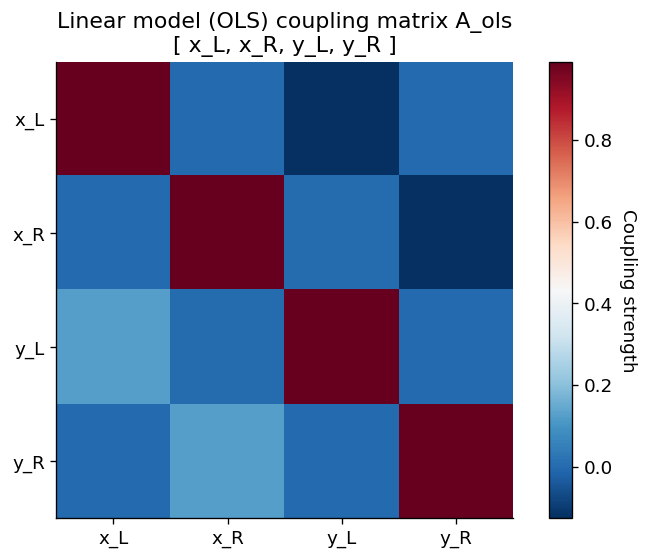

Linear model (OLS) eigenvalues:
  λ = +0.991952+0.125764j   |λ| = 0.99989237  (decays)
  λ = +0.991952-0.125764j   |λ| = 0.99989237  (decays)
  λ = +0.990169+0.125859j   |λ| = 0.99813550  (decays)
  λ = +0.990169-0.125859j   |λ| = 0.99813550  (decays)

One-step RMSE: 0.003378  ← near zero, looks perfect
Free-run RMSE: 0.098496  ← grows as errors compound over time


In [ ]:
# ─── Fit linear model ──────────────────────────────────────
A_ols, state = fit_linear_model_ols(z_L_h, z_R_h)

# ─── show coupling matrix and eigenvalues ──────────────────────────────────


# INSERT CODE HERE


# ─── simulate the model ──────────────────────────────────

# One-step vs free-run
onestep = (A_ols @ state[:-1].T).T
onestep_rmse = np.sqrt(np.mean((onestep - state[1:])**2))

# ─── noise-free vs. noisy free-run simulation ──────────────────────────────────────


# INSERT CODE HERE


freerun_rmse = np.sqrt(np.mean((z_free - state)**2))

print(f'\nOne-step RMSE: {onestep_rmse:.6f}  ← near zero, looks perfect')
print(f'Free-run RMSE: {freerun_rmse:.6f}  ← grows as errors compound over time')


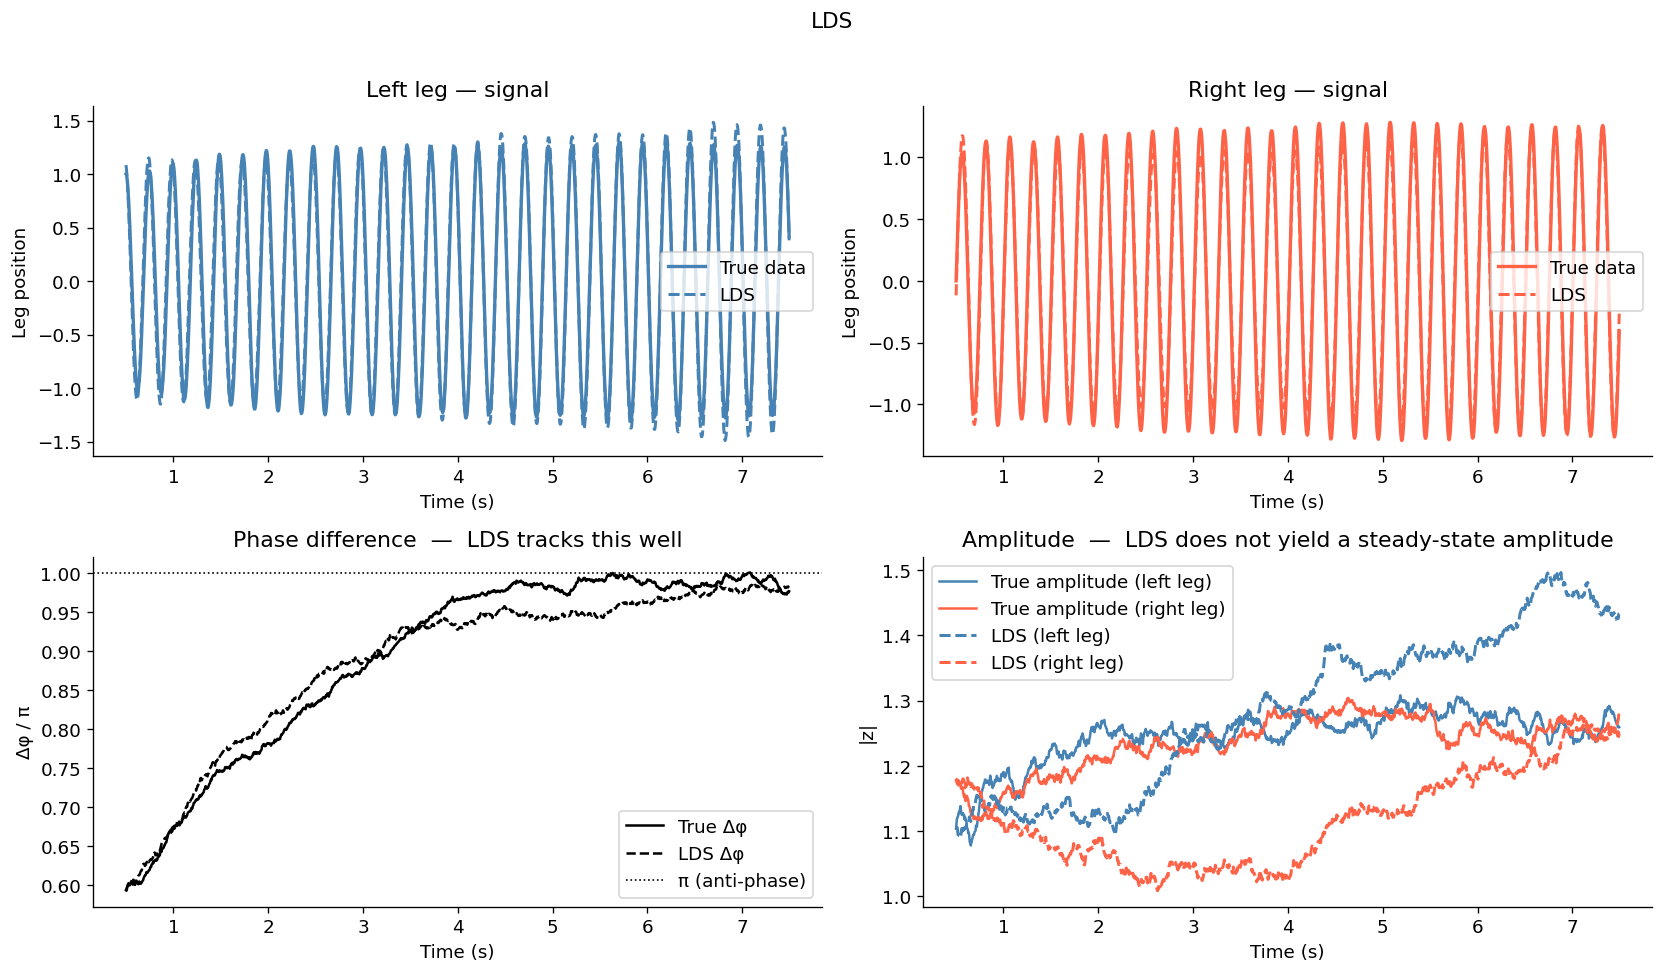

In [295]:

# ─── Figure: LDS — what it captures and what it misses ─────
n_show_val = int(7.0 / dt)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top row: time series
ax = axes[0, 0]
ax.plot(t[:n_show_val], df.x_L[:n_show_val], 'steelblue', lw=2, label='True data')
ax.plot(t[:n_show_val], z_free[:n_show_val, 0], 'steelblue', ls='--', lw=1.8, label='LDS')
ax.set_title('Left leg — signal')
ax.set_xlabel('Time (s)'); ax.legend()
ax.set_ylabel('Leg position')

ax = axes[0, 1]
ax.plot(t[:n_show_val], df.x_R[:n_show_val], 'tomato', lw=2, label='True data')
ax.plot(t[:n_show_val], z_free[:n_show_val, 1], 'tomato', ls='--', lw=1.8, label='LDS')
ax.set_title('Right leg — signal')
ax.set_xlabel('Time (s)'); ax.legend()
ax.set_ylabel('Leg position')

dphi_true_test = phi_L_h - phi_R_h   # phi_L_h, phi_R_h from Part 2

z_lin = z_free[:, 0] + 1j * z_free[:, 2]
r_L_lin = np.abs(z_lin)
phi_L_lin = np.unwrap(np.angle(z_lin))
z_lin = z_free[:, 1] + 1j * z_free[:, 3]
r_R_lin = np.abs(z_lin)
phi_R_lin = np.unwrap(np.angle(z_lin))
dphi_K_test    = (phi_L_lin - phi_R_lin) % (2*np.pi)

ax = axes[1, 0]
ax.plot(t[:n_show_val], dphi_true_test[:n_show_val] / np.pi, 'black', lw=1.5, label='True Δφ')
ax.plot(t[:n_show_val], dphi_K_test[:n_show_val]   / np.pi, 'black', ls='--', lw=1.5, label='LDS Δφ')
ax.axhline(1.0, color='k', ls=':', lw=1, label='π (anti-phase)')
ax.set_title('Phase difference  —  LDS tracks this well')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Δφ / π'); ax.legend()

# Bottom row: amplitude
ax = axes[1, 1]
ax.plot(t[:n_show_val], r_L_h[:n_show_val], 'steelblue', lw=1.5, label='True amplitude (left leg)')
ax.plot(t[:n_show_val], r_R_h[:n_show_val], 'tomato', lw=1.5, label='True amplitude (right leg)')
ax.plot(t[:n_show_val], r_L_lin[:n_show_val], 'steelblue', ls='--', lw=1.8, label='LDS (left leg)')
ax.plot(t[:n_show_val], r_R_lin[:n_show_val], 'tomato', ls='--', lw=1.8, label='LDS (right leg)')
ax.set_title('Amplitude  —  LDS does not yield a steady-state amplitude')
ax.set_xlabel('Time (s)'); ax.set_ylabel('|z|'); ax.legend()

plt.suptitle(
    'LDS',
    fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

- **LDS tracks the phase difference well.**
- **It does not reach a steady-state amplitude (due to noise and systematic drift - which becomes visible for longer simulation times; see next figure).**
- **Both the noise and the systematic drift drive the amplitude away from a constant amplitude observed in walking.**

<span style="color:green">**Task**: Now run the simulation for a much longer time (let's say 60 seconds of simulated walking). What do you observe?</span>

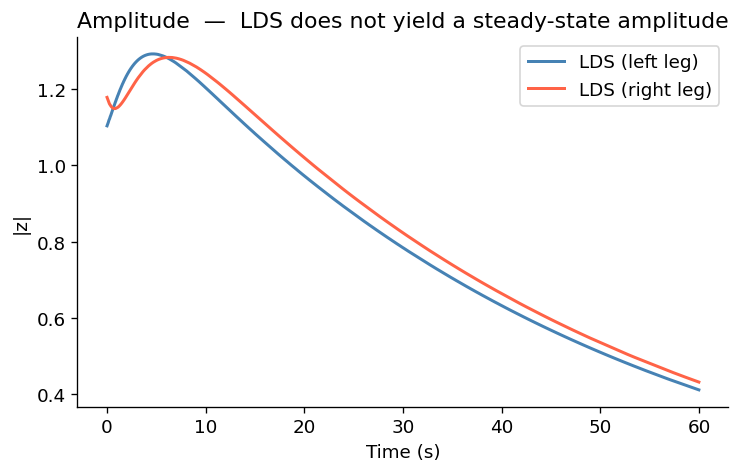

In [ ]:


# INSERT YOUR CODE HERE.


---
## Part 4 — Stage 2: The Kuramoto model

### 4.1 The simplest possible model of leg coordination

Suppose each leg has an intrinsic rhythm — a phase $\theta_k(t)$ that advances at rate $\omega_k$ — and the legs influence each other. The simplest model is:

$$\dot{\theta}_k = \omega_k + \sum_{j \neq k} \kappa_{kj} \sin(\theta_j - \theta_k)$$

This is the **Kuramoto model** (Kuramoto 1984). The $\sin$ term has a beautiful intuition: if leg $j$ is ahead of leg $k$ ($\theta_j > \theta_k$), positive $\kappa_{kj}$ accelerates leg $k$ to catch up. Negative $\kappa_{kj}$ repels — pushing the legs toward anti-phase ($\Delta\theta = \pi$).

**Key feature:** there is no amplitude variable. Each oscillator lives purely on the unit circle. This is both its strength (simplicity) and its weakness (amplitude blindness).


<span style="color:green">**Task**: Fit the Kuramoto model.</span>

In [ ]:
# ─── Fit the Kuramoto model by OLS ───────────────────────────────
# Model: dφ_L/dt = ω + κ_eff · sin(φ_R − φ_L)
#        dφ_R/dt = ω + κ_eff · sin(φ_L − φ_R)

dphi_dt_L = np.gradient(phi_L_h, dt)
dphi_dt_R = np.gradient(phi_R_h, dt)

def fit_kuramoto_ols(dphi_dt, sin_coupling):


INSERT CODE HERE.

# Estimate from one oscillator only (both legs give near-identical ω, κ by symmetry)
omega_K, kappa_K = fit_kuramoto_ols (...)

print('─── Kuramoto fit ───────────────────────────────────────')
print(f'Fit   ω = {omega_K:.3f} rad/s  ({omega_K/(2*np.pi):.2f} Hz)')
print()
print(f'Fit   κ = {kappa_K:.3f}  (Kuramoto effective coupling)')
print()
print(f'κ < 0  →  anti-phase (Δφ = π) is the stable fixed point  ✓')

─── Kuramoto fit ───────────────────────────────────────
Fit   ω = 25.213 rad/s  (4.01 Hz)

Fit   κ = -0.287  (Kuramoto effective coupling)

κ < 0  →  anti-phase (Δφ = π) is the stable fixed point  ✓


<span style="color:green">**Task**: Implement the Kuramoto model (solve with simple Euler integration).</span>

In [ ]:
# ─── Simulate a free-running Kuramoto model ───────────────────────
# The Kuramoto model: dθ_k/dt = ω + κ·sin(θ_j − θ_k)
# To generate an observable x_k(t), we project back: x_k = cos(θ_k)
# (unit-amplitude — the Kuramoto model has no amplitude information)

N_val = x_L.shape[0]
t_val = np.arange(N_val) * dt

def simulate_kuramoto(omega, kappa, dt, N, phi0=None, rng=None):
    """Simple Euler integration of 2-oscillator Kuramoto model."""
    if rng is None: rng = np.random.default_rng()
    phi = np.zeros((N, 2))
    phi[0] = phi0 if phi0 is not None else [0., np.pi]
    sigma_K = 0.03  # small phase noise
    

    INSERT CODE HERE.
    
    
    return phi

# Initial phase from the start of the test window
phi_K = simulate_kuramoto(omega_K, kappa_K, dt, N_val,
                           phi0=[phi_L_h[0], phi_R_h[0]], rng=np.random.default_rng(55))

# Kuramoto 'prediction': unit-amplitude sinusoid at fitted phase
r_K = 0.5 * r_L_h.mean() + 0.5 * r_R_h.mean()

x_K_L = r_K * np.cos(phi_K[:, 0])   # scaled to observed mean amplitude for visual comparison
x_K_R = r_K * np.cos(phi_K[:, 1])

x_test = np.vstack((x_L,x_R)).T

print(f'Kuramoto model simulated: {N_val} steps = {N_val*dt:.1f} s')


Kuramoto model simulated: 1400 steps = 7.0 s


### 4.2 The Kuramoto model: what it gets right, what it misses

Before looking at the plots, let's predict what should happen:

- **Phase coordination**: the Kuramoto model was *fit* to phase data, so it should track phase well
- **Amplitude**: the Kuramoto model has *no amplitude variable* — it will always output a perfect sinusoid with amplitude $r_K$. It cannot represent any fluctuation, change, or perturbation of amplitude.

This is not a failure of fitting. It is a fundamental limitation of the model class.

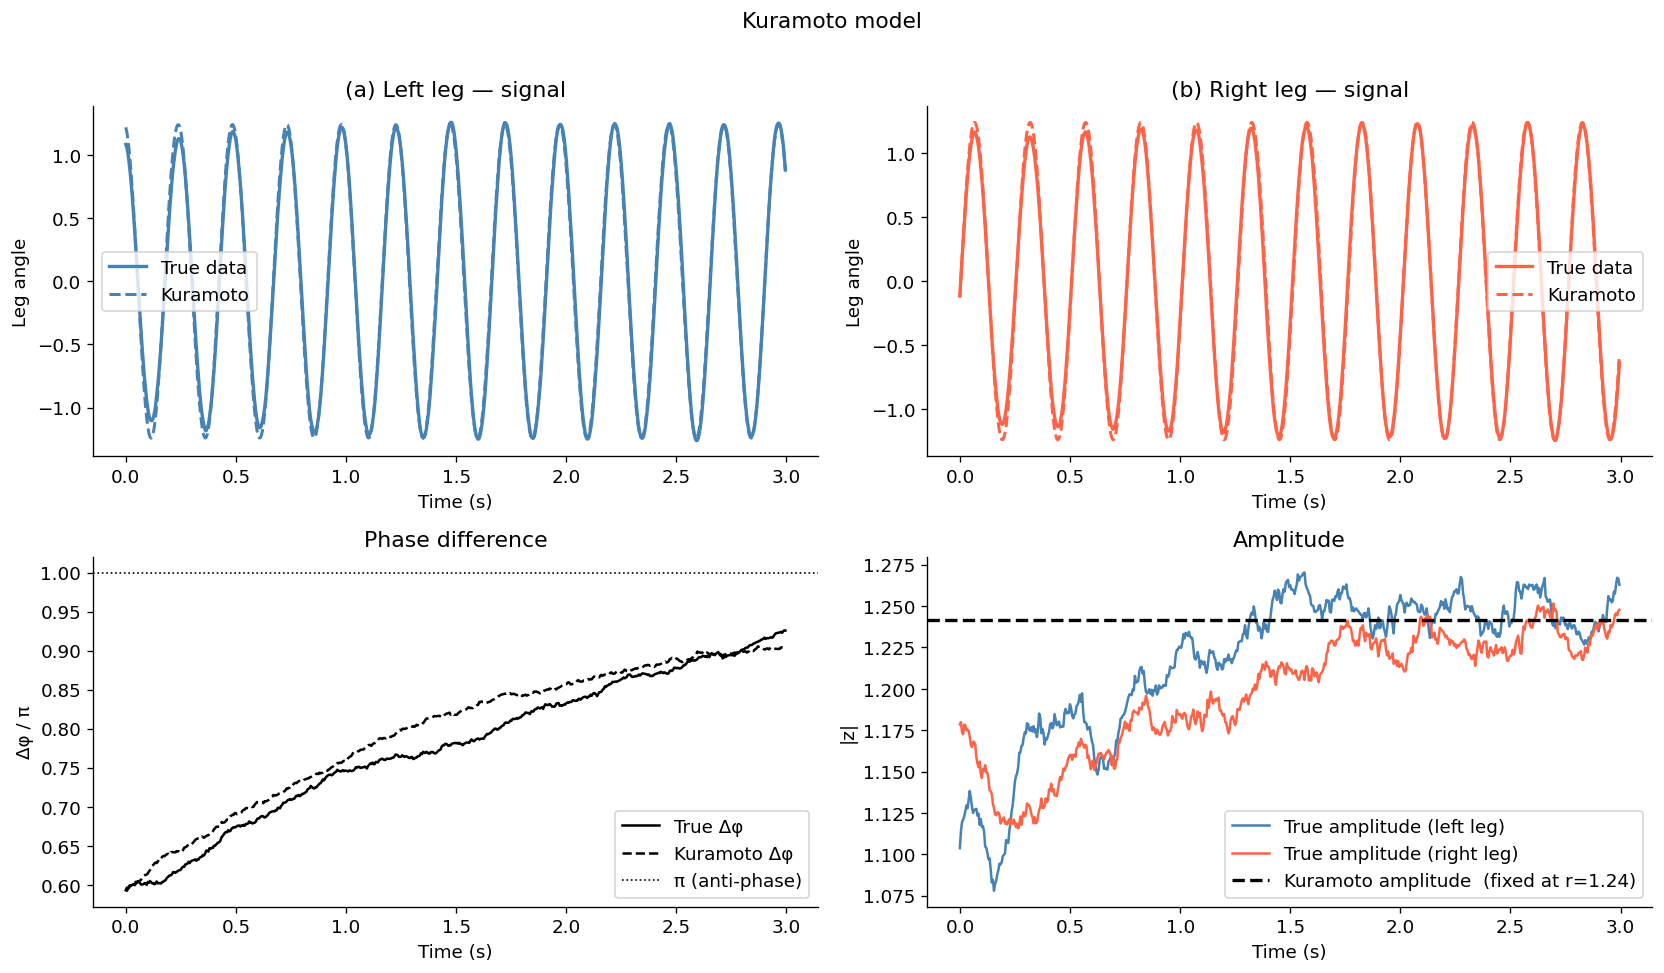

In [301]:
# ─── Figure: Kuramoto — what it captures and what it misses ─────
n_show_val = int(3.0 / dt)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top row: time series
ax = axes[0, 0]
ax.plot(t_val[:n_show_val], x_test[:n_show_val, 0], 'steelblue', lw=2, label='True data')
ax.plot(t_val[:n_show_val], x_K_L[:n_show_val],    'steelblue', ls='--', lw=1.8, label='Kuramoto')
ax.set_title('(a) Left leg — signal')
ax.set_xlabel('Time (s)'); ax.legend()
ax.set_ylabel('Leg angle')

ax = axes[0, 1]
ax.plot(t_val[:n_show_val], x_test[:n_show_val, 1], 'tomato', lw=2, label='True data')
ax.plot(t_val[:n_show_val], x_K_R[:n_show_val],    'tomato', ls='--', lw=1.8, label='Kuramoto')
ax.set_title('(b) Right leg — signal')
ax.set_xlabel('Time (s)'); ax.legend()
ax.set_ylabel('Leg angle')

ax = axes[1, 0]
dphi_true_test = phi_L_h - phi_R_h
dphi_K_test    = (phi_K[:, 0] - phi_K[:, 1]) % (2*np.pi)
ax.plot(t_val[:n_show_val], dphi_true_test[:n_show_val] / np.pi, 'black', lw=1.5, label='True Δφ')
ax.plot(t_val[:n_show_val], dphi_K_test[:n_show_val]   / np.pi, 'black', ls='--', lw=1.5, label='Kuramoto Δφ')
ax.axhline(1.0, color='k', ls=':', lw=1, label='π (anti-phase)')
ax.set_title('Phase difference')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Δφ / π'); ax.legend()

# Bottom row: amplitude — where Kuramoto fails
amp_L_test = r_L_h
amp_R_test = r_R_h

ax = axes[1, 1]
ax.plot(t_val[:n_show_val], amp_L_test[:n_show_val], 'steelblue', lw=1.5, label='True amplitude (left leg)')
ax.plot(t_val[:n_show_val], amp_R_test[:n_show_val], 'tomato', lw=1.5, label='True amplitude (right leg)')
ax.axhline(r_K, color='black', ls='--', lw=2,
           label=f'Kuramoto amplitude  (fixed at r={r_K:.2f})')
ax.set_title('Amplitude')
ax.set_xlabel('Time (s)'); ax.set_ylabel('|z|'); ax.legend()

plt.suptitle(
    'Kuramoto model',
    fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

- **The Kuramoto model is excellent at phase coordination.** 
- **However, it is completely blind to amplitude.**

### 4.3 The stable fixed point of the Kuramoto model

What does the Kuramoto model predict about which phase relationship will be stable?

Subtract the two phase equations: let $\Delta\phi = \theta_L - \theta_R$. Then:
$$\dot{\Delta\phi} = \kappa\sin(-\Delta\phi) - \kappa\sin(\Delta\phi) = -2\kappa\sin(\Delta\phi)$$

Fixed points where $\dot{\Delta\phi} = 0$: $\Delta\phi \in \{0, \pi\}$. Stability: $d(\dot{\Delta\phi})/d(\Delta\phi) = -2\kappa\cos(\Delta\phi)$.

<span style="color:green">**Task**: Plot $-2\kappa\cos(\Delta\phi)$ as a function of the phase difference $\Delta\phi$ and reason about the stability of the fixed points. What happens if $\kappa$ takes positive values?</span>

- At $\Delta\phi = 0$: stable iff $\kappa > 0$ (in-phase gait)
- At $\Delta\phi = \pi$: stable iff $\kappa < 0$ (anti-phase gait — our case)

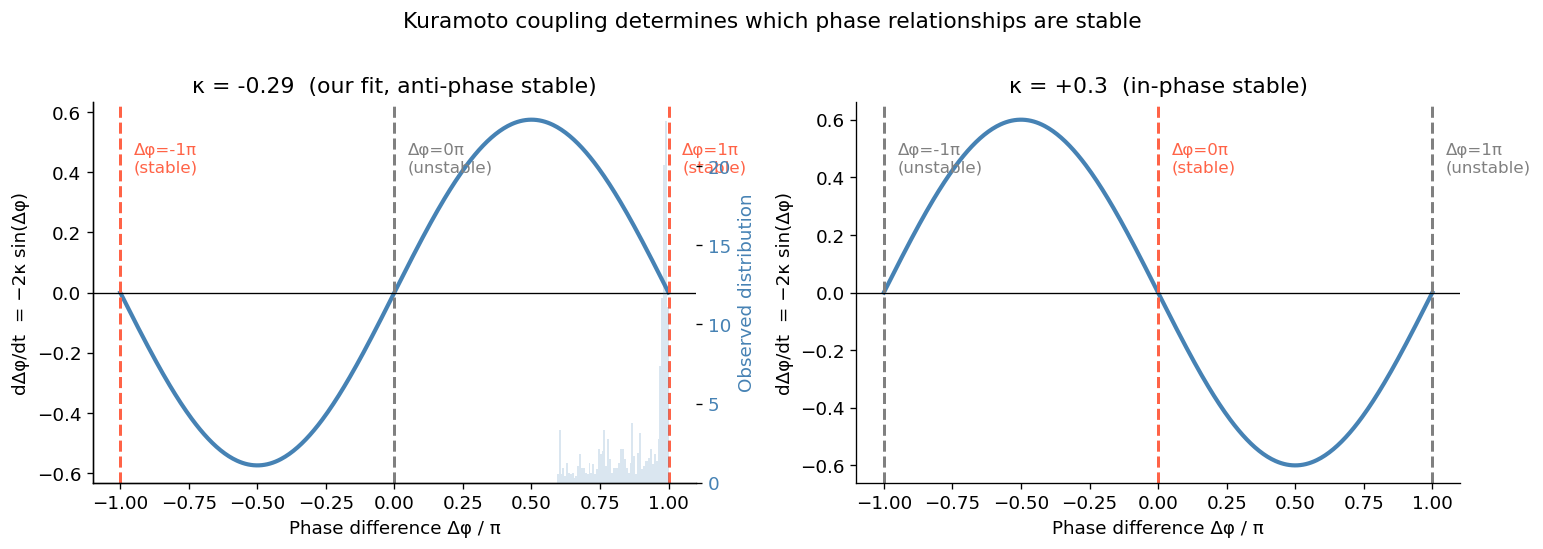

In [ ]:

INSERT YOUR CODE HERE.


**Kuramoto summary**:
for κ_fit < 0  →  anti-phase (Δφ=π) is the stable gait.

If we fit the 6 legs, we would get a 6×6 coupling matrix κ_ij directly encoding the wiring diagram of gait coordination.

In a real tripod gait: within-tripod κ > 0 (in-phase), across-tripod κ < 0 (anti-phase).

---
## Part 5 — Stage 3: The Stuart-Landau model

### 5.1 Adding amplitude to Kuramoto: the Hopf normal form

The fix is simple: instead of constraining the oscillator to a circle, let it live in the full $(x, y)$ plane, with a nonlinear term that *attracts* trajectories to a circle of radius $r^*$.

In complex notation $z_k = x_k + iy_k$:

$$\underbrace{\dot{z}_k = (\mu + i\omega)z_k}_{\text{linear: growth + rotation}} \underbrace{- |z_k|^2 z_k}_{\text{cubic saturation}} + \kappa(z_{\bar k} - z_k) + \sigma\xi_k$$

In **polar coordinates** $(r_k, \theta_k)$ this separates beautifully:

$$\dot{r}_k = r_k(\mu - r_k^2) + \text{coupling amplitude terms}$$
$$\dot{\theta}_k = \omega + \text{coupling phase terms}$$

Near the limit cycle ($r_k \approx r^*$), the coupling phase terms reduce to **exactly the Kuramoto form** $\kappa_{\text{eff}}\sin(\theta_j - \theta_k)$. So:

> **Kuramoto is the phase reduction of Stuart-Landau, valid near $r^*$.**

The cubic term $-|z|^2 z$ is what makes the limit cycle an *attractor*: it creates a restoring force in the radial direction.

In [303]:
# ─── Reveal the true generative model ──────────────────────────────
# fly_data.csv was generated from a Stuart-Landau (Hopf) oscillator pair. 
# Here are the ground-truth parameters so that you can compare our fits against the truth.
mu      = 1.0             # bifurcation parameter (controls amplitude)
omega   = 2*np.pi * 4.0   # 4 Hz stepping frequency
kappa   = -0.3            # coupling strength (negative = anti-phase)
sigma   = 0.05            # noise
sqrt_dt = np.sqrt(dt)
r_star  = np.sqrt(mu - 2*kappa)   # steady-state limit-cycle amplitude (anti-phase pair)

def simulate_SL(mu, omega, kappa, sigma, dt, N, z0=None, rng=None):
    """Heun + Euler-Maruyama integration of 2 coupled Stuart-Landau oscillators."""
    if rng is None: rng = np.random.default_rng()
    z = np.zeros((N, 2), dtype=complex)
    z[0] = z0 if z0 is not None else r_star * np.array([1., -1.])
    sqrt_dt_ = np.sqrt(dt)
    def f(z_):
        return (mu + 1j*omega)*z_ - np.abs(z_)**2*z_ + kappa*(z_[::-1] - z_)
    for n in range(N - 1):
        k1 = f(z[n]); k2 = f(z[n] + dt*k1)
        noise = (rng.standard_normal(2) + 1j*rng.standard_normal(2)) * sigma * sqrt_dt_
        z[n+1] = z[n] + 0.5*dt*(k1 + k2) + noise
    return z

print(f'True generative parameters: μ={mu}, ω={omega:.3f} ({omega/(2*np.pi):.1f} Hz), '
      f'κ={kappa}, σ={sigma}, r*={r_star:.3f}')




True generative parameters: μ=1.0, ω=25.133 (4.0 Hz), κ=-0.3, σ=0.05, r*=1.265


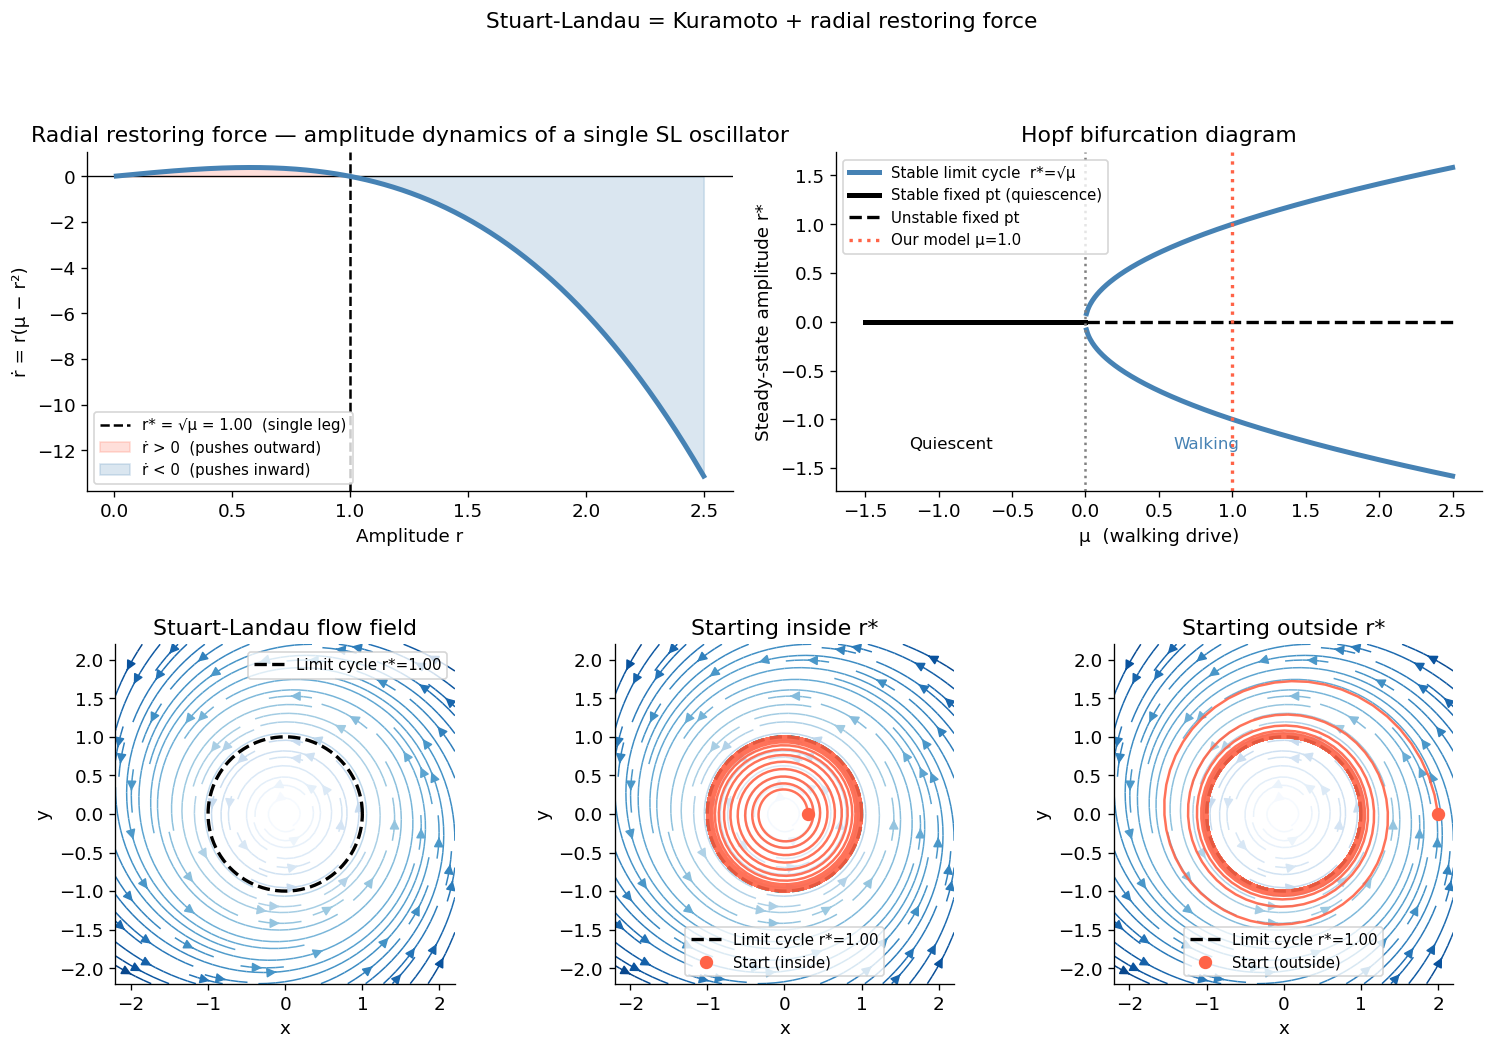

In [305]:
# ─── Figure: The radial restoring force in the SL model ───
r_vals = np.linspace(0.01, 2.5, 400)
r_dot_single = r_vals * (mu - r_vals**2)   # ṙ for uncoupled SL
r_star_single = np.sqrt(mu)

fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.45, wspace=0.7)

# (a) Radial restoring force
ax = fig.add_subplot(gs[0, 0:3])
ax.axhline(0, color='k', lw=0.8)
ax.axvline(r_star_single, color='k', ls='--', lw=1.5,
           label=f'r* = √μ = {r_star_single:.2f}  (single leg)')
ax.plot(r_vals, r_dot_single, 'steelblue', lw=3)
ax.fill_between(r_vals, r_dot_single, 0,
                where=(r_vals < r_star_single), color='tomato',
                alpha=0.2, label='ṙ > 0  (pushes outward)')
ax.fill_between(r_vals, r_dot_single, 0,
                where=(r_vals > r_star_single), color='steelblue',
                alpha=0.2, label='ṙ < 0  (pushes inward)')
ax.set_xlabel('Amplitude r'); ax.set_ylabel('ṙ = r(μ − r²)')
ax.set_title('Radial restoring force — amplitude dynamics of a single SL oscillator')
ax.legend(fontsize=9)

# (b) Hopf bifurcation diagram
mu_range = np.linspace(-1.5, 2.5, 500)
ax = fig.add_subplot(gs[0, 3:6])
mu_pos = mu_range[mu_range > 0]
ax.plot(mu_pos,  np.sqrt(mu_pos), 'steelblue', lw=3, label='Stable limit cycle  r*=√μ')
ax.plot(mu_pos, -np.sqrt(mu_pos), 'steelblue', lw=3)
ax.plot(mu_range[mu_range <= 0], np.zeros(np.sum(mu_range <= 0)),
        'k-', lw=3, label='Stable fixed pt (quiescence)')
ax.plot(mu_range[mu_range > 0], np.zeros(np.sum(mu_range > 0)),
        'k--', lw=2, label='Unstable fixed pt')
ax.axvline(0, color='gray', ls=':', lw=1.5)
ax.axvline(mu, color='tomato', ls=':', lw=2, label=f'Our model μ={mu}')
ax.set_xlabel('μ  (walking drive)'); ax.set_ylabel('Steady-state amplitude r*')
ax.set_title('Hopf bifurcation diagram')
ax.legend(fontsize=9)
ax.text(0.6, -1.3, 'Walking', color='steelblue', fontsize=10)
ax.text(-1.2, -1.3, 'Quiescent', color='k', fontsize=10)

# ─── Shared flow field for panels (c)-(e): the single, uncoupled SL oscillator ───
# (no kappa term here, so its limit cycle sits at r_star_single = sqrt(mu), not the
# coupled r_star used elsewhere in this notebook)
def sl_field(x, y, mu_v):
    r2 = x**2 + y**2
    return mu_v*x - omega*y - r2*x, omega*x + mu_v*y - r2*y

xs_g = np.linspace(-2.2, 2.2, 18)
X, Y = np.meshgrid(xs_g, xs_g)
DX, DY = sl_field(X, Y, mu)
speed = np.sqrt(DX**2 + DY**2) + 1e-8

def sl_trajectory(r0, mu_v, n_steps=3000, h=0.005):
    """Heun (RK2) integration of a single SL trajectory starting at (r0, 0).
    Plain Euler is not accurate enough here: omega*h ~ 0.13 rad/step, and over
    many periods that error accumulates into spurious amplitude growth (same
    reason simulate_SL above uses Heun rather than Euler)."""
    traj = np.zeros((n_steps + 1, 2))
    traj[0] = [r0, 0]
    def f(p):
        return np.array(sl_field(p[0], p[1], mu_v))
    for n in range(n_steps):
        k1 = f(traj[n])
        k2 = f(traj[n] + h*k1)
        traj[n + 1] = traj[n] + 0.5*h*(k1 + k2)
    return traj

def draw_flow_field(ax, title):
    ax.streamplot(X, Y, DX/speed, DY/speed, color=speed, cmap='Blues',
                  density=1.3, linewidth=0.9, arrowsize=1.2)
    ax.plot(r_star_single*np.cos(theta_lc), r_star_single*np.sin(theta_lc),
            'k--', lw=2, label=f'Limit cycle r*={r_star_single:.2f}')
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title)

# (c) Flow field only
ax = fig.add_subplot(gs[1, 0:2])
draw_flow_field(ax, 'Stuart-Landau flow field')
ax.legend(fontsize=9)

# (d) Trajectory starting inside the limit cycle => spirals outward onto the limit cycle
ax = fig.add_subplot(gs[1, 2:4])
draw_flow_field(ax, 'Starting inside r*')
traj_in = sl_trajectory(0.3, mu)
ax.plot(traj_in[:, 0], traj_in[:, 1], color='tomato', lw=1.5, alpha=0.9)
ax.plot(traj_in[0, 0], traj_in[0, 1], 'o', ms=7, color='tomato', label='Start (inside)')
ax.legend(fontsize=9)

# (e) Trajectory starting outside the limit cycle => spirals inward onto the limit cycle
ax = fig.add_subplot(gs[1, 4:6])
draw_flow_field(ax, 'Starting outside r*')
traj_out = sl_trajectory(2.0, mu)
ax.plot(traj_out[:, 0], traj_out[:, 1], color='tomato', lw=1.5, alpha=0.9)
ax.plot(traj_out[0, 0], traj_out[0, 1], 'o', ms=7, color='tomato', label='Start (outside)')
ax.legend(fontsize=9)

plt.suptitle('Stuart-Landau = Kuramoto + radial restoring force', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

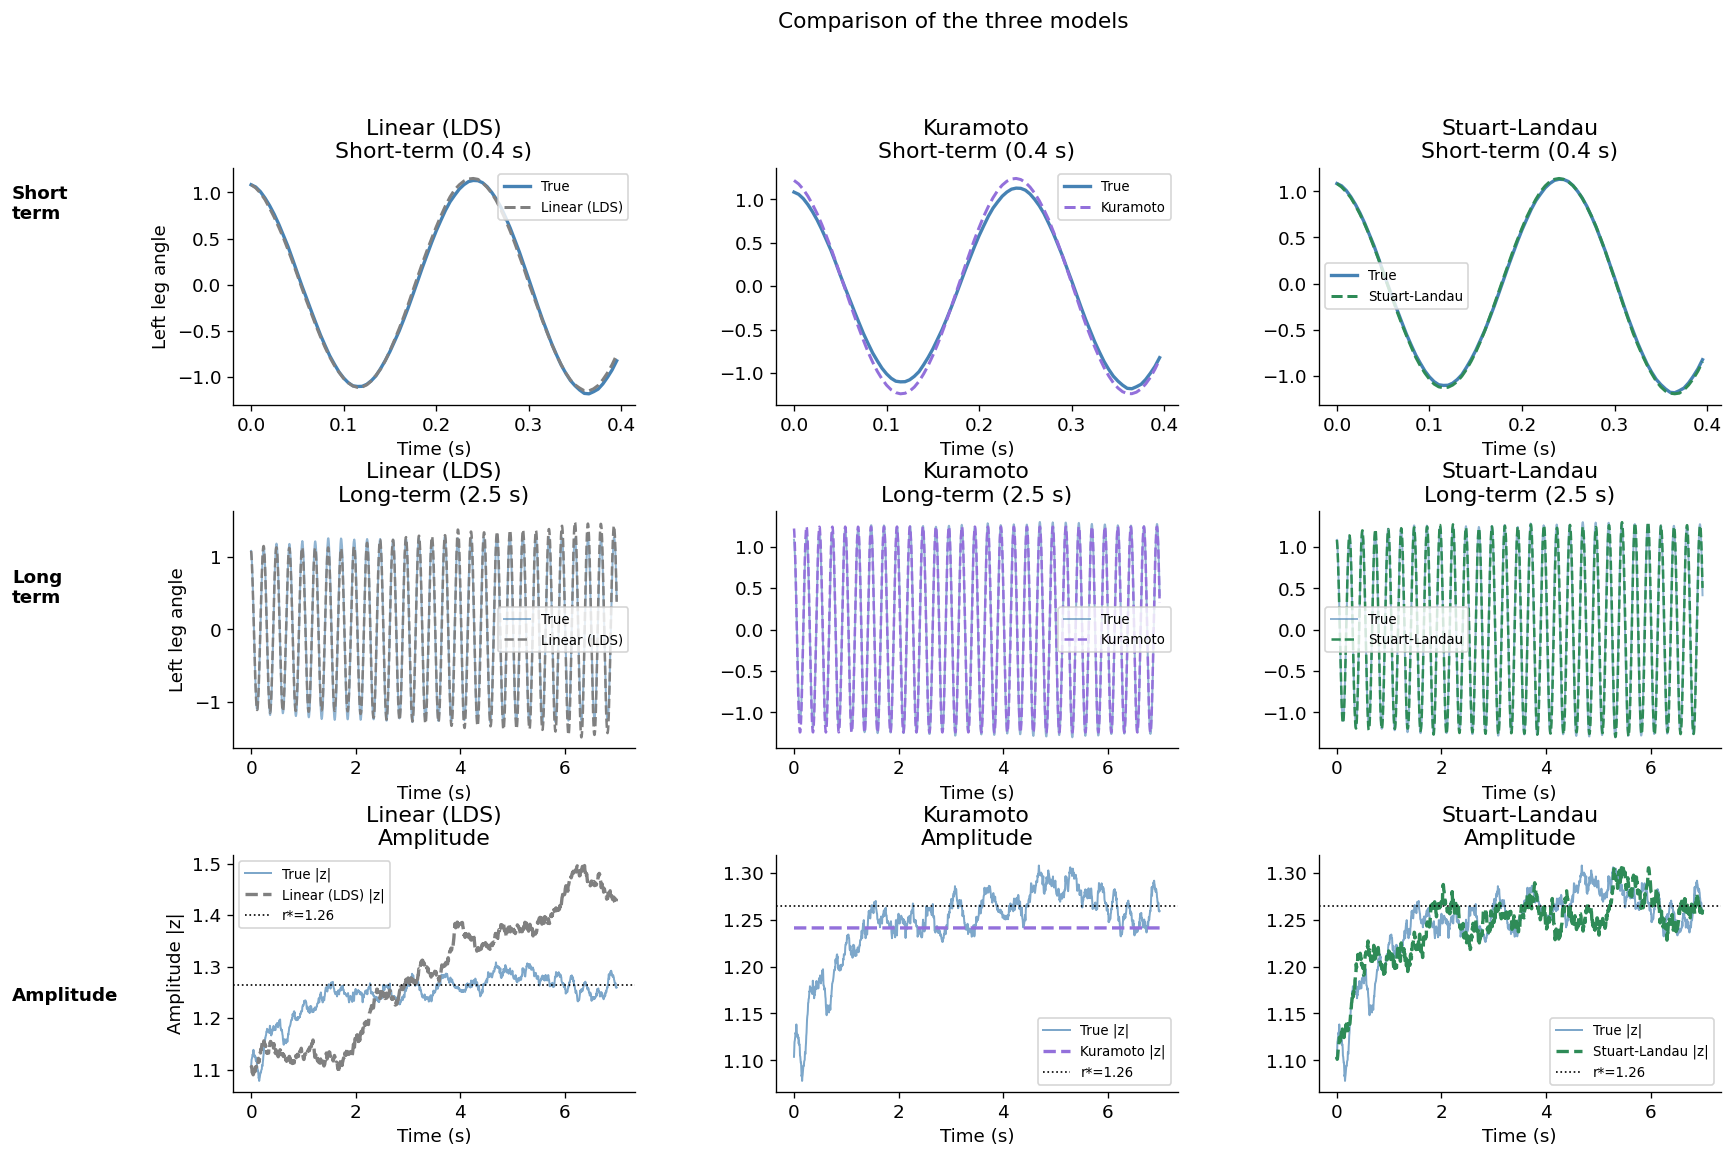

Summary:
  Linear (LDS):   short-term ✓  |  long-term ✗ (diverges)  |  amplitude ✗
  Kuramoto:       short-term ✓  |  long-term ✓ (phase)    |  amplitude ✗ (rigid circle)
  Stuart-Landau:  short-term ✓  |  long-term ✓            |  amplitude ✓


In [ ]:
# ─── Figure: The three models compared — one-step vs free-run ───
# Reuse the Part 4 evaluation window (post-warmup test window) under a shared name
N_eval     = N_val
t_eval     = t_val
state_eval = x_test    # observed (x_L, x_R), shape (N_val, 2)

# linear model free-run (already computed above, re-run for same window)
z_free = simulate_linear_model(A_ols, state[0], N_eval,
        sigma=noise_std, rng=np.random.default_rng(0))       # with realistic noise
x_L_lin = z_free[:, 0]
r_L_lin  = np.sqrt(z_free[:, 0]**2 + z_free[:, 2]**2)

# Kuramoto free-run (already computed above, re-run for same window)
phi_K_eval = simulate_kuramoto(omega_K, kappa_K, dt, N_eval,
                                phi0=[phi_L_h[0], phi_R_h[0]],
                                rng=np.random.default_rng(77))
x_L_K = r_K * np.cos(phi_K_eval[:, 0])

# SL free-run using the true (ground-truth) parameters
z_SL_eval = simulate_SL(mu, omega, kappa, sigma, dt, N_eval,
                         z0=np.array([z_L_h[0], z_R_h[0]]),  # analytic-signal estimate of initial (x, y)
                         rng=np.random.default_rng(88))
x_L_SL = z_SL_eval[:, 0].real
r_L_SL   = np.abs(z_SL_eval[:, 0])

n_short = int(0.4 / dt)
n_long  = int(7 / dt)

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

titles_col = ['Linear (LDS)', 'Kuramoto', 'Stuart-Landau']
colors_col  = ['gray', 'mediumpurple', 'seagreen']
preds_long = [x_L_lin, x_L_K, x_L_SL]
preds_short = [x_L_lin[:n_short], x_L_K[:n_short], x_L_SL[:n_short]]

# Row 1: short-term (0.4 s)
for col, (title, color, pred) in enumerate(zip(titles_col, colors_col, preds_short)):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(t_val[:n_short], state_eval[:n_short, 0], 'steelblue', lw=2, label='True')
    ax.plot(t_eval[:n_short], pred[:n_short], color=color, ls='--', lw=1.8, label=title)
    ax.set_title(f'{title}\nShort-term')
    ax.set_xlabel('Time (s)')
    if col == 0: ax.set_ylabel('Left leg angle')
    ax.legend(fontsize=8)

# Row 2: long-term (7 s)
for col, (title, color, pred) in enumerate(zip(titles_col, colors_col, preds_long)):
    ax = fig.add_subplot(gs[1, col])
    ax.plot(t_val[:n_long], state_eval[:n_long, 0], 'steelblue', lw=1.2, alpha=0.6, label='True')
    ax.plot(t_eval[:n_long], pred[:n_long], color=color, ls='--', lw=1.5, label=title)
    ax.set_title(f'{title}\nLong-term')
    ax.set_xlabel('Time (s)')
    if col == 0: ax.set_ylabel('Left leg angle')
    ax.legend(fontsize=8)

# Row 3: amplitude over time
ampl_list   = [r_L_lin, np.full(N_eval, r_K), r_L_SL]
for col, (title, color, r_pred) in enumerate(zip(titles_col, colors_col, ampl_list)):
    ax = fig.add_subplot(gs[2, col])
    ax.plot(t_val, r_L_h, 'steelblue', lw=1.2, alpha=0.7, label='True |z|')
    ax.plot(t_eval, r_pred, color=color, ls='--', lw=2, label=f'{title} |z|')
    ax.axhline(r_star, color='k', ls=':', lw=1, label=f'r*={r_star:.2f}')
    ax.set_xlabel('Time (s)')
    if col == 0: ax.set_ylabel('Amplitude |z|')
    ax.set_title(f'{title}\nAmplitude')
    ax.legend(fontsize=8)

# Row labels
fig.text(0.01, 0.85, 'Short\nterm', fontsize=11, color='k',
         fontweight='bold', va='center')
fig.text(0.01, 0.53, 'Long\nterm', fontsize=11, color='k',
         fontweight='bold', va='center')
fig.text(0.01, 0.19, 'Amplitude', fontsize=11, color='k',
         fontweight='bold', va='center')

plt.suptitle(
    'Comparison of the three models',
    fontsize=13, y=1.01)
plt.show()

print('Summary:')
print(f'  Linear (LDS):   short-term ✓  |  long-term ✗ (diverges)  |  amplitude ✗')
print(f'  Kuramoto:       short-term ✓  |  long-term ✓ (phase)    |  amplitude ✗ (rigid circle)')
print(f'  Stuart-Landau:  short-term ✓  |  long-term ✓            |  amplitude ✓')

---
## Part 6 — Perturbation and recovery of gait coordination

A walking fly is constantly buffeted by small disturbances — uneven terrain, gusts of air, contact with other flies. A good model of locomotion should not just describe the steady state; it should explain why the fly keeps walking normally after a perturbation.
Here, we consider an amplitude perturbation: what happens if a leg's oscillation amplitude is briefly pushed off the limit cycle — say, by a mechanical disturbance that increases or decreases step size? The three models make sharply different predictions:

- **Kuramoto**: cannot represent amplitude perturbation at all. A phase kick is possible, but amplitude restoration has no mechanism.
- **Linear (LDS)**: the amplitude is permanently displaced — there is no restoring force
- **Stuart-Landau**: both amplitude and phase recover — the limit cycle attracts from all directions


<span style="color:green">**Task**: Simulate amplitude perturbations in the linear dynamical system and in the 2 coupled Stuart-Landau oscillators. Hint: a reasonable kick could be to apply an external input of strength 0.05 for 200 ms to the system.</span>


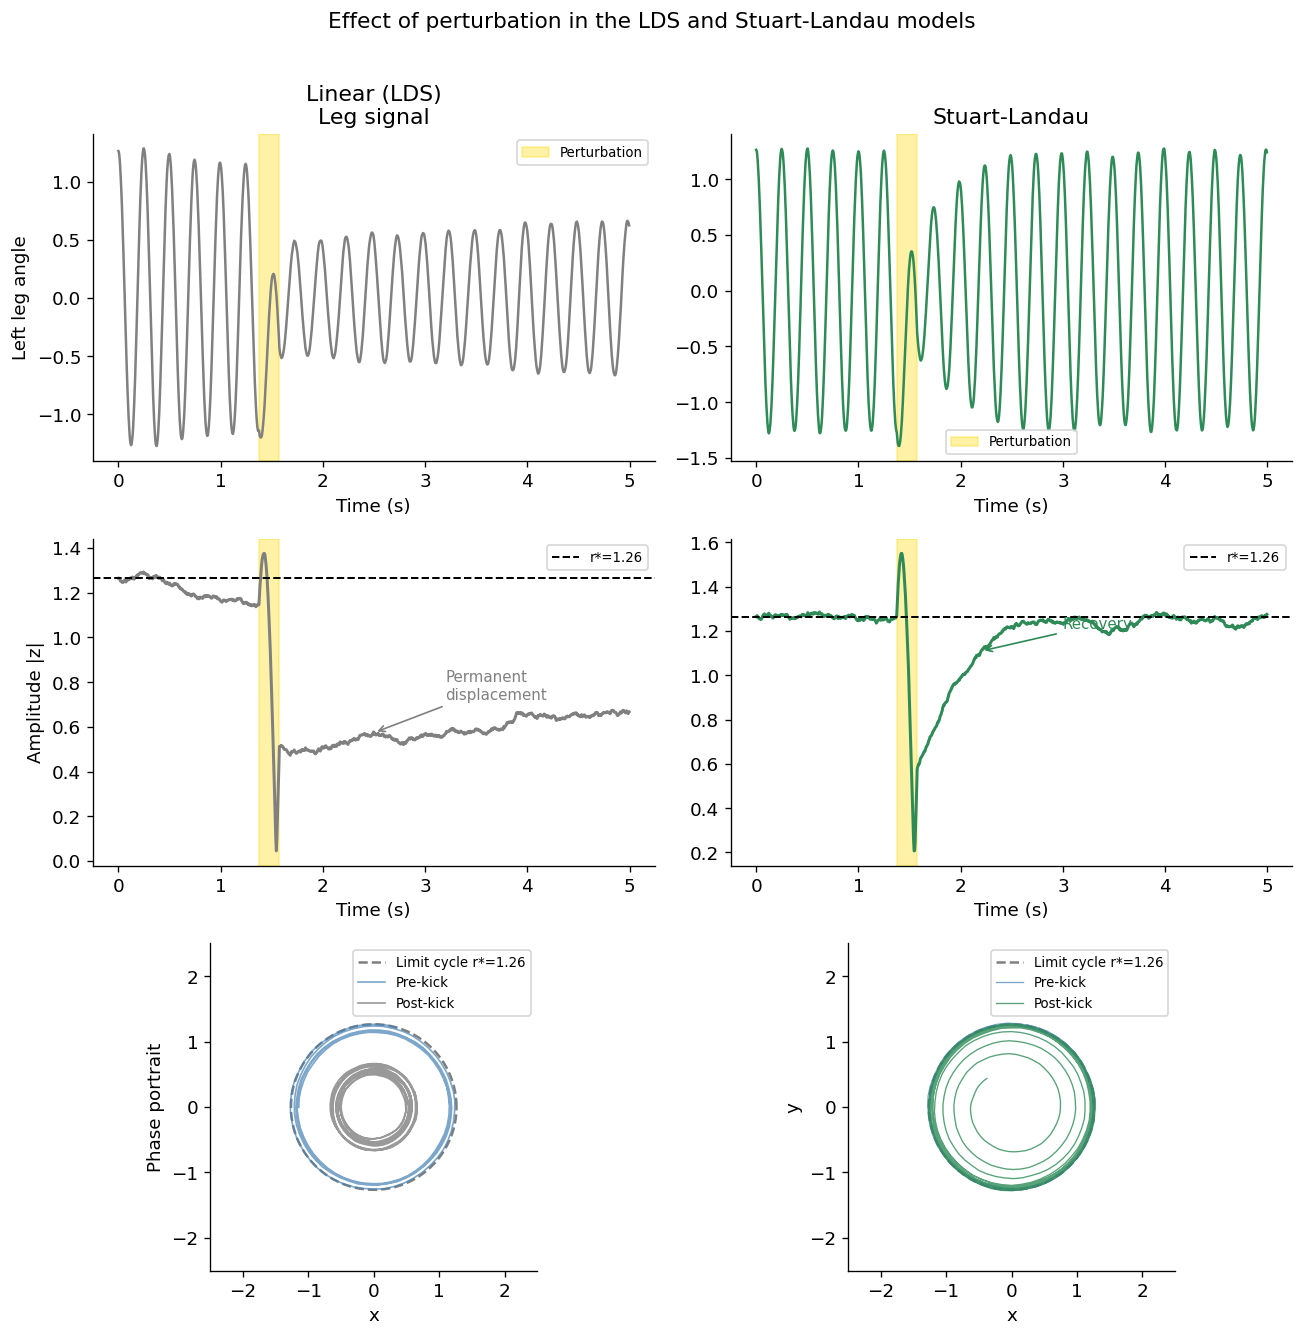

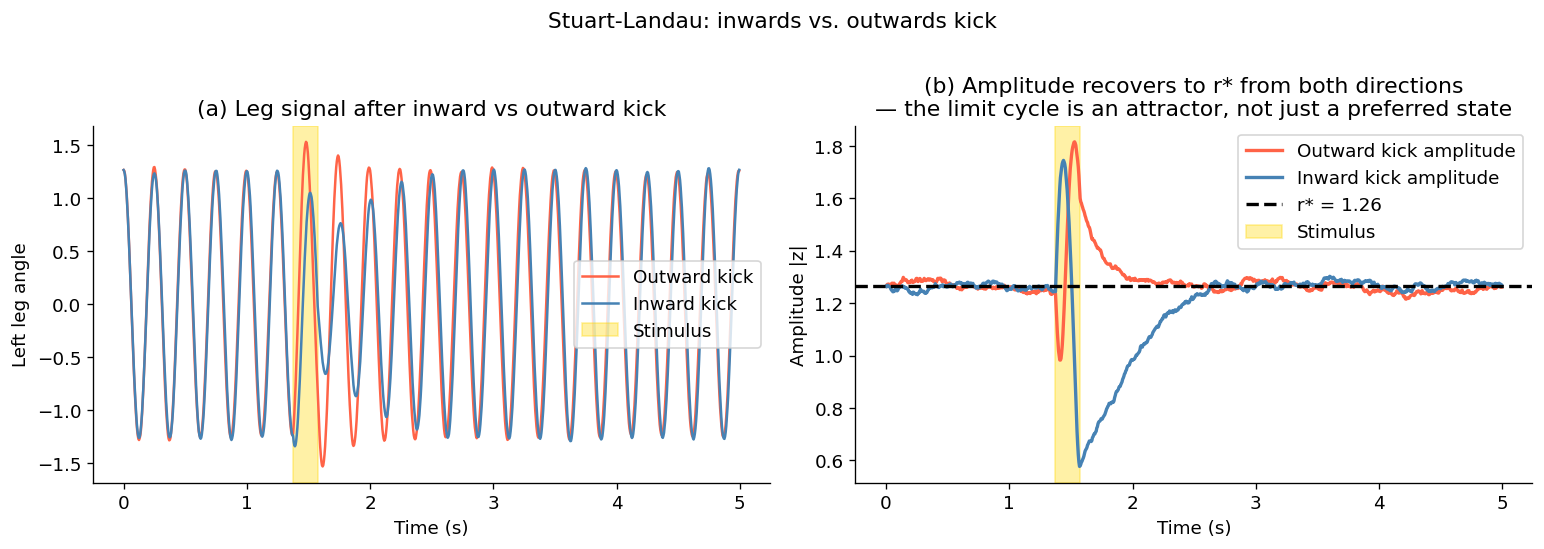

Amplitude 1.0s after stimulus:
  Outward kick: r = 1.267   (true r* = 1.265)
  Inward kick:  r = 1.232   (true r* = 1.265)
Both recover to within 0.033 of r*


---
## Summary

### The three-model comparison

| | **Linear (LDS)** | **Kuramoto** | **Stuart-Landau** |
|---|---|---|---|
| State | $z \in \mathbb{R}^{2N}$ | $\theta \in [0,2\pi)^N$ | $z \in \mathbb{C}^N$ |
| Amplitude variable | ✓ (implicit) | ✗ (always r*) | ✓ (explicit) |
| Phase coordination | ✓ one-step | ✓ | ✓ |
| Long-run stability | ✗ diverges/decays | ✓ (phase only) | ✓ (amplitude + phase) |
| Walking onset/offset | ✗ | ✗ | ✓ via μ crossing 0 |
| Perturbation recovery | ✗ permanent shift | ✗ phase only | ✓ amplitude + phase |
| Moonwalker experiment | ✗ | ✗ | ✓ |
| Fitting cost | Very easy (OLS) | Easy (Hilbert + OLS) | Easy (Hilbert + 2×OLS) |
| # parameters (2 legs) | 16 (4×4 matrix) | 3 (ω, κ, noise) | 4 (μ, ω, κ, noise) |
| Analytic theory | Rich (LTI) | Rich (Kuramoto) | Moderate (normal form) |

### Kuramoto as the phase reduction of Stuart-Landau

This is the key conceptual link:

$$\text{Stuart-Landau:  }\dot{z} = (\mu+i\omega)z - |z|^2z + \kappa(z_j - z_k)$$

$$\xrightarrow{r \to r^*,\; \text{project onto phase}}$$

$$\text{Kuramoto:  }\dot{\theta}_k = \omega + \kappa_{\text{eff}}\sin(\theta_j - \theta_k)$$

Kuramoto is not a separate model — it is Stuart-Landau **projected onto the limit cycle**. It is exact in the limit of zero noise and perturbation, and a good approximation whenever $|r - r^*| \ll r^*$.

### Exercises

**Exercise 1 (Kuramoto stability):** Set `kappa = +0.3` in the Kuramoto simulation. What phase difference does the system converge to? Is it anti-phase or in-phase? Does the Stuart-Landau system behave the same?

**Exercise 2 (noise sensitivity):** Vary `sigma` from 0.01 to 0.3. For each value, compute the standard deviation of the amplitude fluctuations and the phase coherence $R = |\langle e^{i\theta_k}\rangle|$. At what noise level does the Kuramoto approximation break down?

**Exercise 3 (Hopf bifurcation):** Sweep `mu` from −1.0 to +2.0. For each value, simulate 5 s and compute mean amplitude. Plot $r^*$ vs $\mu$. Does the empirical curve match $\sqrt{\mu - 2\kappa}$? What happens to the Kuramoto model as $\mu \to 0$?

**Exercise 4 (moonwalker analysis):** In the real moonwalker data, measure the amplitude time course before, during, and after optogenetic stimulation. Fit a single exponential recovery $r(t) = r^* + A\, e^{-t/\tau}$ to the post-stimulus amplitude. What is the recovery timescale $\tau$? Can you relate it to the model parameter $\mu$?

**Exercise 5 (6-leg model):** Implement 6 coupled Stuart-Landau oscillators using the schematic coupling matrix. Do within-tripod legs synchronize? What is the steady-state phase pattern? What changes if you set all $\kappa_{ij}$ to the same value?